# LeetCode #278: First Bad Version

https://leetcode.com/problems/first-bad-version/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Call `isBadVersion(i)` for $i = 1, 2, \ldots$ until finding the first `true`. With $n$ up to $2^{31} - 1$, this makes up to ~2 billion API calls — far too slow.

### Optimal: Binary Search ★
The version sequence is `[good, good, …, bad, bad, …, bad]` — a monotone predicate. Binary search for the boundary: if `isBadVersion(mid)` is true, the first bad version is at or before `mid` (`hi = mid`); otherwise it's after (`lo = mid + 1`). Use `lo = hi` termination to avoid overflow when computing `mid`.

**Why this is better than Brute Force:** Reduces API calls from $O(n)$ to $O(\log n)$ — about 31 calls instead of 2 billion for $n = 2^{31} - 1$.

**Constraints:**
* 1 <= bad <= n <= 2^31 - 1

## Solutions

### C#

In [ ]:
/* The isBadVersion API is defined in the parent class VersionControl.
   bool IsBadVersion(int version); */

public class Solution : VersionControl {
    public int FirstBadVersion(int n) {
        int lo = 1, hi = n;
        while (lo < hi) {
            // Avoid overflow: (lo+hi)/2 overflows if both are near INT_MAX
            int mid = lo + (hi - lo) / 2;
            if (IsBadVersion(mid))
                hi = mid;   // first bad is at or before mid
            else
                lo = mid + 1;
        }
        // lo == hi == first bad version
        return lo;
    }
}

### Python

In [ ]:
# The isBadVersion API is already defined for you.
# def isBadVersion(version: int) -> bool:

class Solution:
    def firstBadVersion(self, n: int) -> int:
        lo, hi = 1, n
        while lo < hi:
            mid = lo + (hi - lo) // 2
            if isBadVersion(mid):
                hi = mid   # first bad is at or before mid
            else:
                lo = mid + 1
        # lo == hi == first bad version
        return lo

### Go

In [ ]:
/**
 * Forward declaration of isBadVersion API.
 * @param   version   your guess about first bad version
 * @return 	 	      true if current version is bad
 *			          false if current version is good
 * func isBadVersion(version int) bool;
 */

func firstBadVersion(n int) int {
    lo, hi := 1, n
    for lo < hi {
        mid := lo + (hi-lo)/2
        if isBadVersion(mid) {
            hi = mid   // first bad is at or before mid
        } else {
            lo = mid + 1
        }
    }
    // lo == hi == first bad version
    return lo
}

### Rust

In [ ]:
// The API isBadVersion is defined for you.
// isBadVersion(version: i32)-> bool

impl Solution {
    pub fn first_bad_version(&self, n: i32) -> i32 {
        let (mut lo, mut hi) = (1i64, n as i64);
        while lo < hi {
            let mid = lo + (hi - lo) / 2;
            if self.isBadVersion(mid as i32) {
                hi = mid;   // first bad is at or before mid
            } else {
                lo = mid + 1;
            }
        }
        // lo == hi == first bad version
        lo as i32
    }
}

## Example Scenarios

**1. Common Case**
**Input:** n=5, bad=4
lo=1, hi=5 → mid=3, isBadVersion(3)=false → lo=4. mid=4, isBadVersion(4)=true → hi=4. lo==hi → return 4. Two API calls.

**2. Slightly Complex**
**Input:** n=10, bad=6
lo=1, hi=10 → mid=5, false → lo=6. mid=8, true → hi=8. mid=7, true → hi=7. mid=6, true → hi=6. lo==hi → return 6. Four API calls for n=10.

**3. Edge Case: Time Factor**
**Input:** n = 2^31 − 1, bad = 2^31 − 1 (very last version is first bad)
Binary search makes $\lfloor \log_2(2^{31}-1) \rfloor = 30$ calls. Each call returns `false` until the final step where `lo == hi == 2^31-1`. Without overflow-safe `mid = lo + (hi-lo)/2`, `(lo+hi)/2` wraps negative.

**4. Edge Case: Space Factor**
**Input:** n = 2^31 − 1, bad = 1 (very first version is bad)
lo=1, hi=2^31−1 → mid=~10^9, isBadVersion=true → hi=mid. Continues narrowing until lo=hi=1. Only 3 integers used (lo, hi, mid) — $O(1)$ space regardless of $n$.

**5. Almost-Impossible but Plausible**
**Input:** n=1, bad=1
lo=1, hi=1 → loop condition `lo < hi` is false immediately. Return lo=1. Single version; loop never executes. No API call needed — but the problem guarantees bad exists, so this is safe.

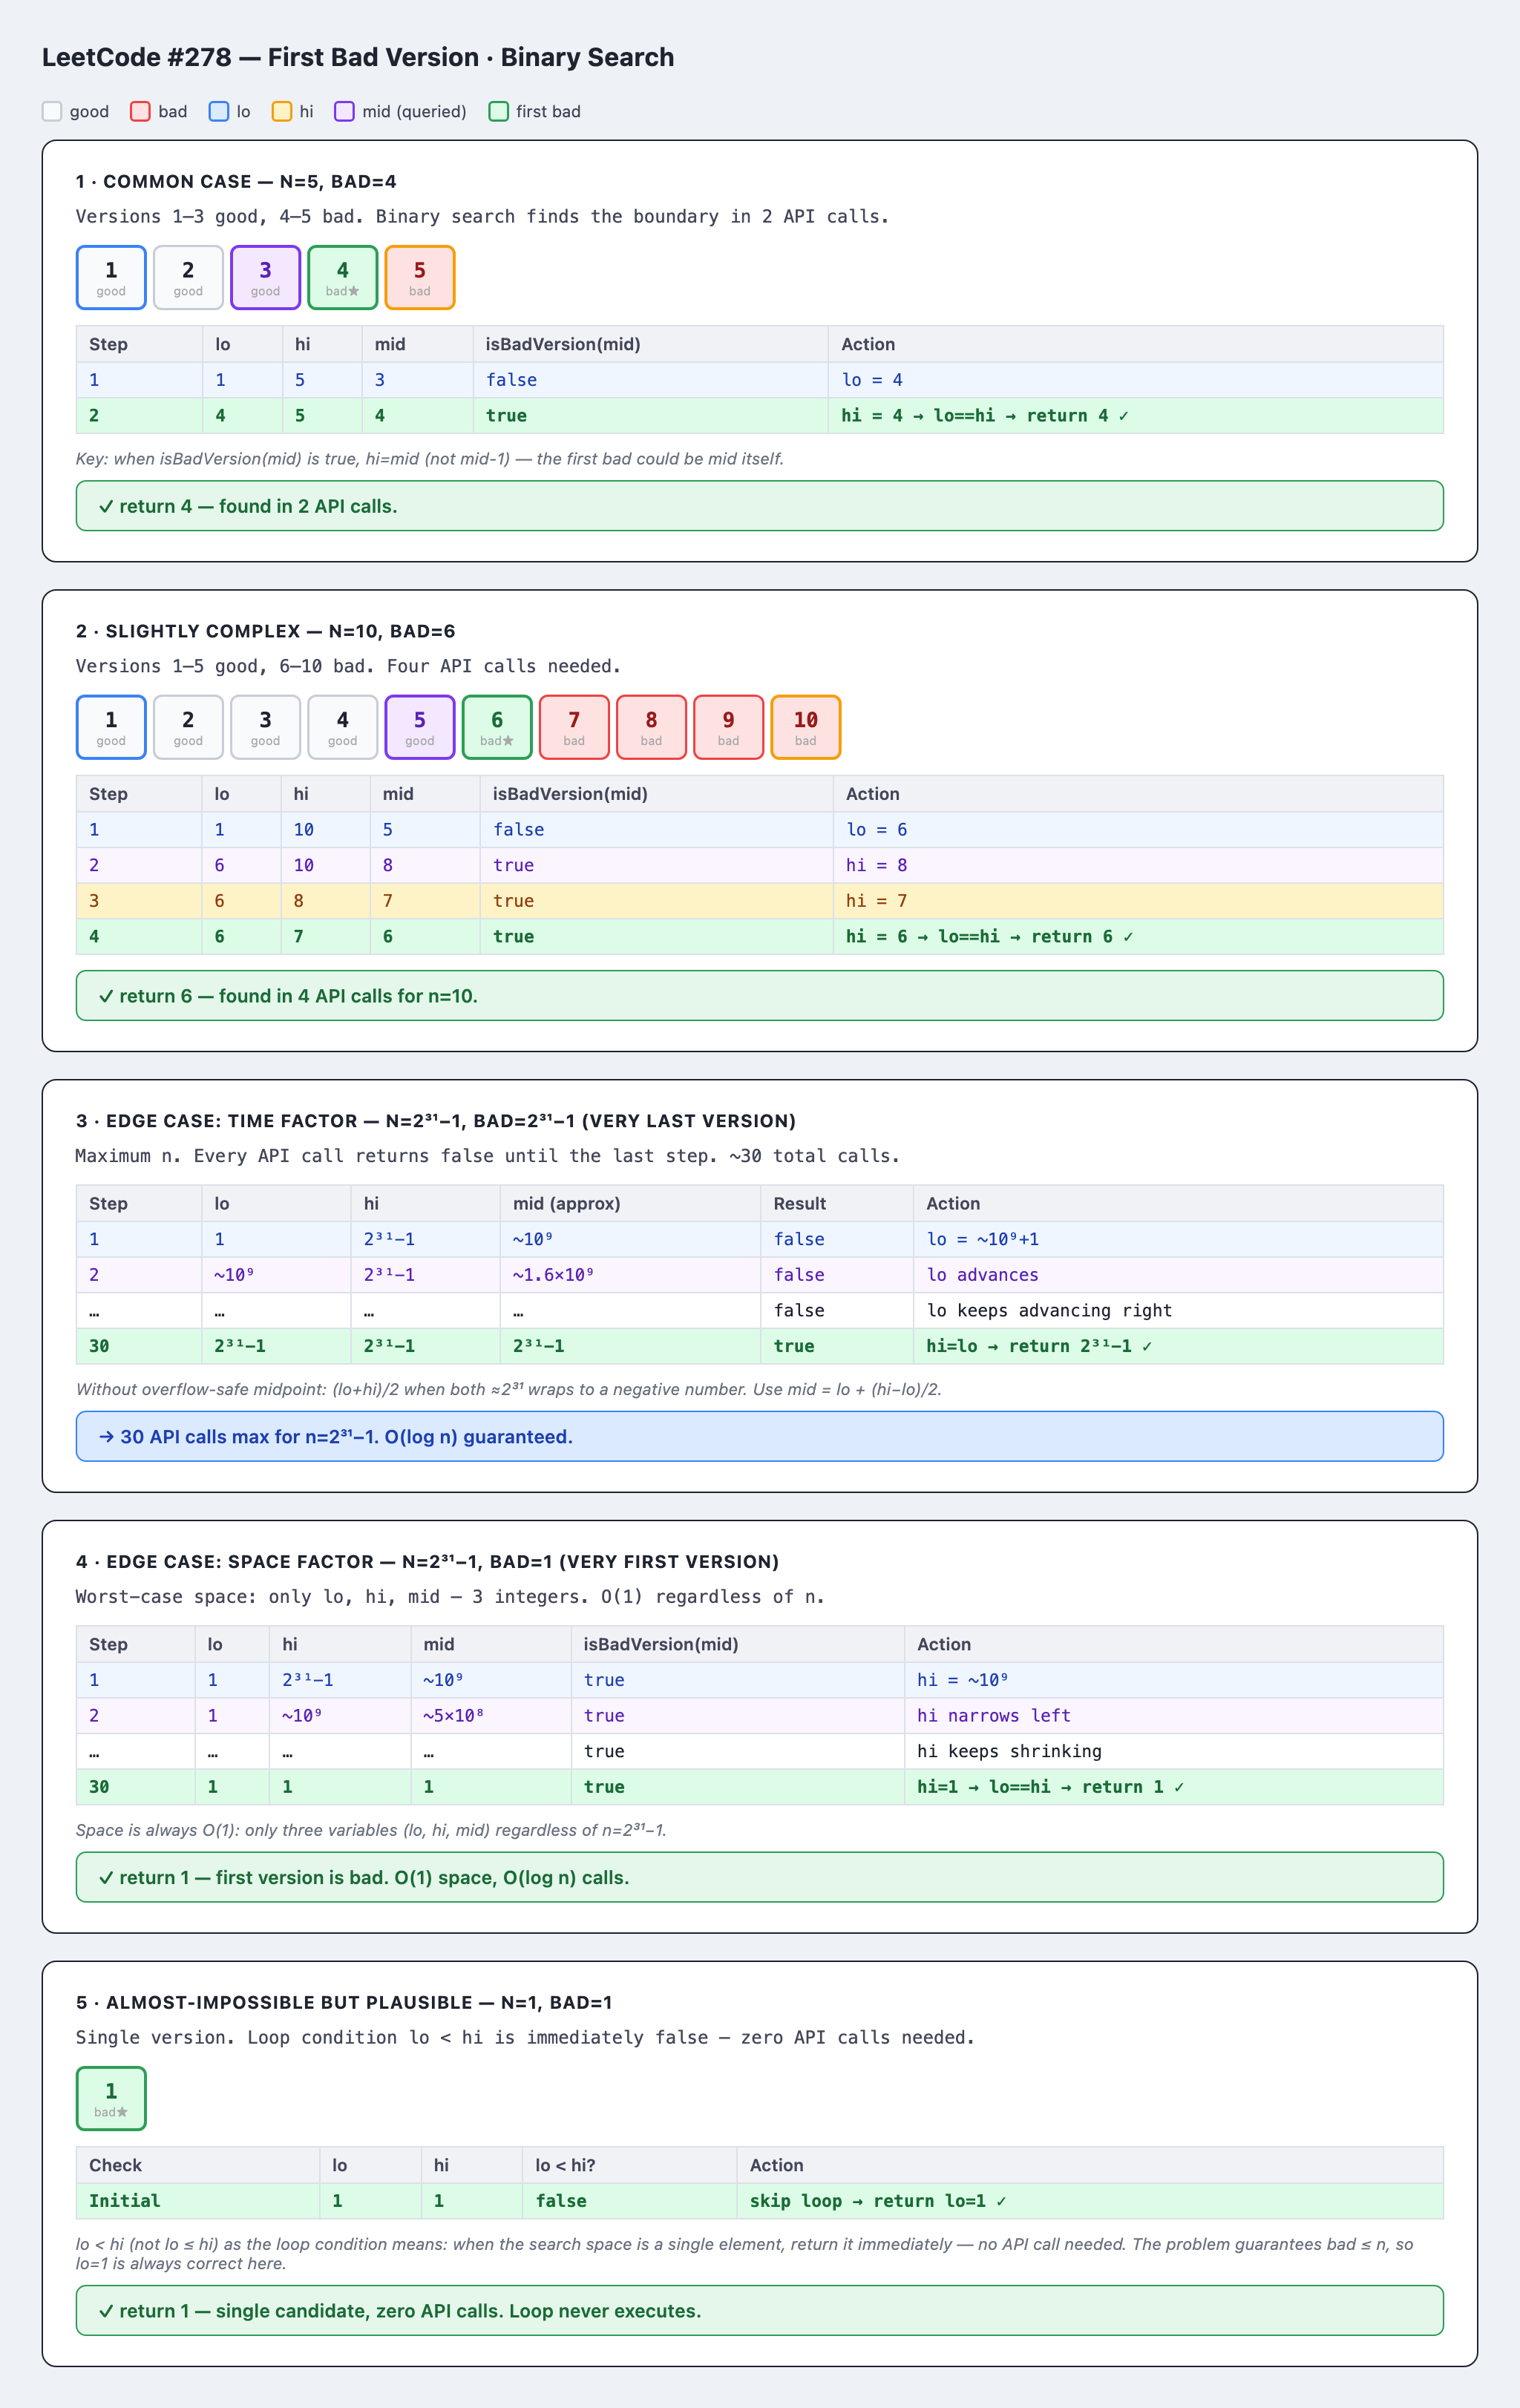